# Segment 3: Dataset Exemplars — Grounding Neurons in Real Images

In Segment 2, we used **activation maximization** to generate synthetic images that maximally excite neurons in `mixed4a`. Those "dream images" reveal what a neuron is *capable* of responding to, but they exist in an idealized pixel space unconstrained by natural image statistics.

This segment takes the complementary approach: instead of optimizing pixels, we **search through a fixed dataset** to find the real-world images that most strongly activate each neuron. This grounds our understanding of neuron behavior in actual data.

We use **Imagenette** — a publicly available 10-class subset of ImageNet (~13K real ImageNet images) — as our search corpus. No authentication required.

### Why Both Views Matter
- **Activation Maximization** (Segment 2): Shows the neuron's "platonic ideal" — what it *wants* to see.
- **Dataset Exemplars** (This Segment): Shows what the neuron *actually fires on* given real images — complete with context, noise, and naturalistic correlations.

Together, they form a more complete picture of what each neuron has learned.

> **Runtime:** Make sure you are using a **GPU runtime** in Colab (`Runtime > Change runtime type > T4 GPU`).

In [ ]:
# 1. Install Dependencies
!pip install torch-lucent

# 2. Download Imagenette (10-class subset of ImageNet, ~330MB, no auth required)
!wget -q https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-320.tgz
!tar -xzf imagenette2-320.tgz

# 3. Imports
import torch
import numpy as np
import matplotlib.pyplot as plt
import heapq
from PIL import Image
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from lucent.modelzoo import inceptionv1

print("Setup complete.")

Setup complete.


In [ ]:
# Load InceptionV1 and register a forward hook on mixed4a to capture activations
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = inceptionv1(pretrained=True)
model.to(device).eval()

activations = {}
def hook_fn(module, input, output):
    activations['mixed4a'] = output.detach()

# Register the hook on the mixed4a module
for name, module in model.named_modules():
    if name == 'mixed4a':
        module.register_forward_hook(hook_fn)
        break

print(f"Model loaded on {device}. Hook registered on mixed4a.")

Downloading: "https://github.com/ProGamerGov/pytorch-old-tensorflow-models/raw/master/inception5h.pth" to /root/.cache/torch/hub/checkpoints/inception5h.pth


100%|██████████| 27.0M/27.0M [00:00<00:00, 217MB/s]


Model loaded on cuda. Hook registered on mixed4a.


## Finding the Top Activating Images

For each of the first 10 neurons (channels 0–9) of `mixed4a`, we scan all Imagenette images (train + val, ~13K images) and keep the 10 images that produce the **highest activation**.

**Activation metric:** We use the **mean** activation across the 14×14 spatial grid for each neuron. This captures the overall response — finding images where the neuron fires broadly across the spatial extent, rather than images where a single spatial location happens to spike.

**Efficient tracking:** We use a min-heap of size 10 per neuron. As we scan images, we only keep the current top-10. When a new image scores higher than the current minimum, it replaces it. This avoids storing activations for all images.

In [ ]:
# Preprocessing: Lucent's InceptionV1 expects input in [0, 1] range
preprocess = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

# Load both train and val splits of Imagenette
train_ds = ImageFolder("imagenette2-320/train", transform=preprocess)
val_ds = ImageFolder("imagenette2-320/val", transform=preprocess)
full_ds = torch.utils.data.ConcatDataset([train_ds, val_ds])

loader = DataLoader(full_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

NUM_NEURONS = 10
TOP_K = 10

# For each neuron, maintain a min-heap of (activation_value, unique_id, pil_image, activation_map)
top_images = {n: [] for n in range(NUM_NEURONS)}
uid = 0
img_idx = 0

print(f"Scanning {len(full_ds):,} Imagenette images...")

for batch_tensors, _ in loader:
    batch_tensors = batch_tensors.to(device)
    with torch.no_grad():
        model(batch_tensors)
    acts = activations['mixed4a']  # (B, C, 14, 14)

    for b in range(acts.shape[0]):
        # Recover a display-sized copy from the batch tensor
        display_img = transforms.ToPILImage()(batch_tensors[b].cpu()).resize((150, 150))

        for n in range(NUM_NEURONS):
            val = acts[b, n].mean().item()
            uid += 1
            if len(top_images[n]) < TOP_K or val > top_images[n][0][0]:
                act_map = acts[b, n].cpu().numpy()
                entry = (val, uid, display_img, act_map)
                if len(top_images[n]) < TOP_K:
                    heapq.heappush(top_images[n], entry)
                else:
                    heapq.heapreplace(top_images[n], entry)

        img_idx += 1

    if img_idx % 5000 < 64:
        print(f"  {img_idx:,}/{len(full_ds):,} images processed...")

print(f"Done! Scanned all {len(full_ds):,} images.")

Scanning 13,394 Imagenette images...
  5,056/13,394 images processed...
  10,048/13,394 images processed...
Done! Scanned all 13,394 images.


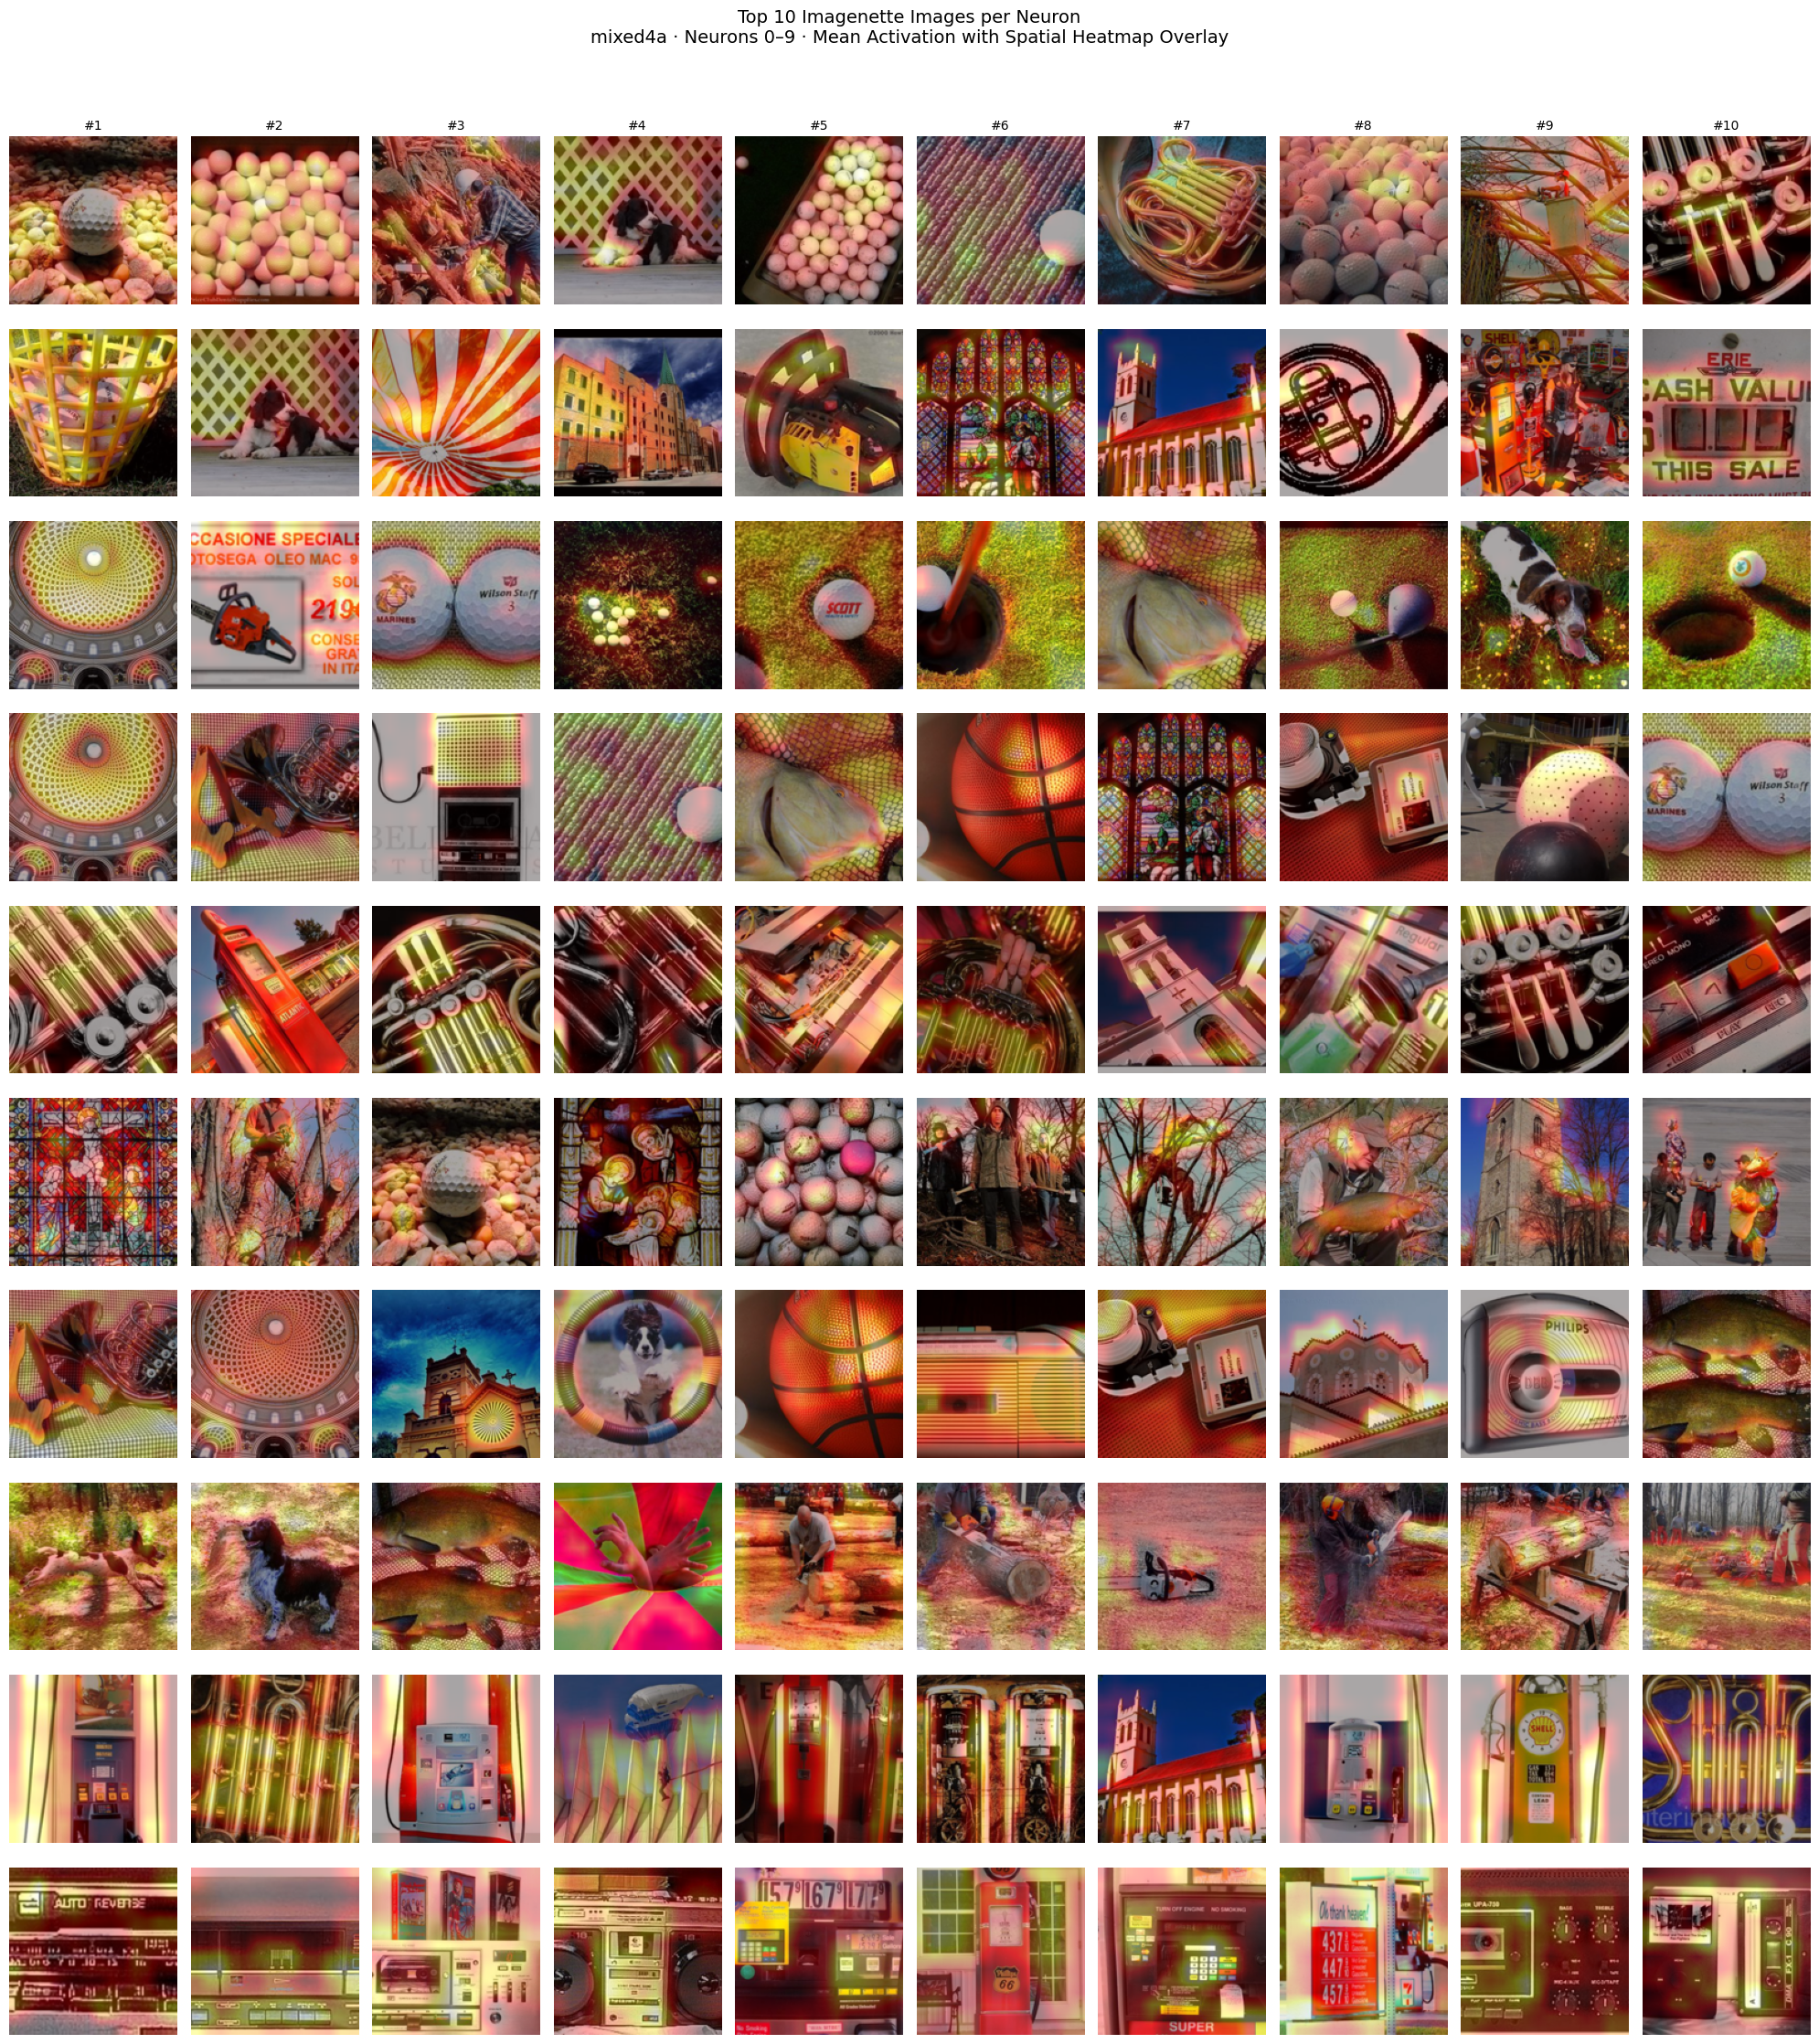

In [ ]:
# Display top 10 images with spatial activation heatmap overlays
fig, axes = plt.subplots(NUM_NEURONS, TOP_K, figsize=(20, 22))

for n in range(NUM_NEURONS):
    ranked = sorted(top_images[n], key=lambda x: -x[0])
    for k in range(TOP_K):
        ax = axes[n][k]
        display_img = ranked[k][2]   # 150x150 PIL image
        act_map = ranked[k][3]       # 14x14 numpy array

        # Show the original image
        ax.imshow(display_img)

        # Overlay the spatial activation map as a heatmap
        act_norm = (act_map - act_map.min()) / (act_map.max() - act_map.min() + 1e-8)
        act_resized = np.array(
            Image.fromarray((act_norm * 255).astype('uint8')).resize((150, 150), Image.BILINEAR)
        )
        ax.imshow(act_resized, cmap='hot', alpha=0.35)

        ax.axis('off')
        if k == 0:
            ax.set_ylabel(f'Neuron {n}', fontsize=11, rotation=0, labelpad=55, va='center')
        if n == 0:
            ax.set_title(f'#{k+1}', fontsize=10)

plt.suptitle(
    "Top 10 Imagenette Images per Neuron\nmixed4a \u00b7 Neurons 0\u20139 \u00b7 Mean Activation with Spatial Heatmap Overlay",
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()

## Observations

Each row above shows the 10 Imagenette images that most strongly activate a given neuron, ranked from strongest (left) to weakest (right). The **hot overlay** shows the spatial activation map — where in the image the neuron fires most intensely. A few things to note:

1. **Coherent themes emerge.** Even though Imagenette spans 10 diverse classes (~13K images), the top activating images for each neuron tend to share a common visual theme — a specific texture, color pattern, shape, or object part. This confirms that neurons in `mixed4a` have developed selective, consistent preferences.

2. **Spatial specificity.** The heatmap overlays reveal *where* in each image the neuron fires. Some neurons respond to localized features (a concentrated bright spot), while others respond more diffusely across the image. This tells us whether the neuron is detecting a local pattern (e.g., a curve or edge) or a more global property (e.g., a color or texture).

3. **Comparison with Activation Maximization.** The synthetic "dream images" from Segment 2 should align with the patterns visible here. Where Segment 2 showed the idealized version of what a neuron responds to, these real images show the natural contexts in which those features occur. Discrepancies between the two can reveal interesting things: a neuron might be more general (responding to a broader class of stimuli) or more specific (only certain instances of the pattern trigger high activation) than the dream image suggests.

4. **Neurons as feature detectors.** The specificity of these results reinforces the idea that individual neurons in intermediate layers serve as reliable feature detectors, each encoding a particular visual concept that the network uses as a building block for downstream classification.

5. **Dataset limitations.** Imagenette contains only 10 of ImageNet's 1,000 classes (tench, English springer, cassette player, chain saw, church, French horn, garbage truck, gas pump, golf ball, parachute). This means neurons sensitive to features not well-represented in these classes may show weaker or less coherent results. Running this same analysis on the full ImageNet validation set (via Hugging Face with authentication) would give a more complete picture.